In [ ]:
%pip install numpy pandas seaborn matplotlib kagglehub tensorflow-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.0/274.0 MB 4.2 MB/s eta 0:00:0000:0100:02

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import kagglehub
import numpy as np 
import pandas as pd
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# computer prepares next training data while learning
AUTOTUNE = tf.data.AUTOTUNE

/home/denise/.pyenv/versions/3.12.7/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
I0000 00:00:1776174649.735423   23157 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [ ]:

path = kagglehub.dataset_download("ninadaithal/imagesoasis")
print("Path to dataset files:", path)

### Preparing the data

In [ ]:
# set to average MRI image pixel sizes (128x128 for lower resolution)
img_height = 128
img_width = 128
batch_number = 20 # train in 20 images at a time

# labels the images based on the folder names (EG 'Mild Dementia')
data_dir = path + "Data/" 

# training dataset: 80% of whole dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2, 
  subset="training",
  seed=123, # set random seed for reproducibility
  image_size=(img_height, img_width),
  batch_size=batch_number)

# validation dataset: 20% of whole dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_number)

Found 86437 files belonging to 4 classes.
Using 69150 files for training.
Found 86437 files belonging to 4 classes.
Using 17287 files for validation.


### Modeling via CNN (Convolutional Neural Network)

In Alzheimer’s, we look for Cortical Atrophy (shrinkage) and Ventricular Enlargement (the fluid-filled spaces getting bigger). These layers are literally searching for those structural changes.

In [5]:
# modelling is done layer by layer
model = models.Sequential([
  # black to white scaled to 0 to 1
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  
  # scan the images for patterns (e.g., lines, curves, shapes) and make 'feature maps' of where those patterns are in the image
    # layer 1 uses 16 filters - scan image for simple patterns
    # MaxPooling2D = Filter for important features only to make it more manageable for the next layer
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.2), # Randomly ignores 20% of neurons to prevent "memorization"

    # layer 2 + 3 uses 32 filters - scan feature maps for more complex patterns
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.2),
  
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.2),

  # make guesses on the severity based on the feature maps
    # flatten = assign feature map to single long vector to feed into the dense layers
    # dense = neurons all connect to previous fully connected layers, learns to make predictions based on the features
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(4, activation='softmax') 
])

# learn by adjusting the model's parameters to minimize the loss 
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

/home/denise/.pyenv/versions/3.12.7/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training the model

In [6]:
epochs = 20
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs,
  steps_per_epoch=50
)

Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 362ms/step - accuracy: 0.7780 - loss: 0.7268 - val_accuracy: 0.7835 - val_loss: 0.8177
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 373ms/step - accuracy: 0.7850 - loss: 0.6810 - val_accuracy: 0.7849 - val_loss: 0.8524
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 361ms/step - accuracy: 0.7780 - loss: 0.6543 - val_accuracy: 0.7946 - val_loss: 0.8237
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 371ms/step - accuracy: 0.7970 - loss: 0.6007 - val_accuracy: 0.7838 - val_loss: 0.6700
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 374ms/step - accuracy: 0.8050 - loss: 0.6104 - val_accuracy: 0.7862 - val_loss: 0.6181
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 375ms/step - accuracy: 0.7870 - loss: 0.5758 - val_accuracy: 0.7905 - val_loss: 0.5824
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 376ms/step - accuracy: 0.7860 - loss: 0.5448 - val_accuracy: 0.8063 - val_loss: 0.5440
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 373ms/step - accuracy: 0.8000 - loss: 0.5229 - val_accu

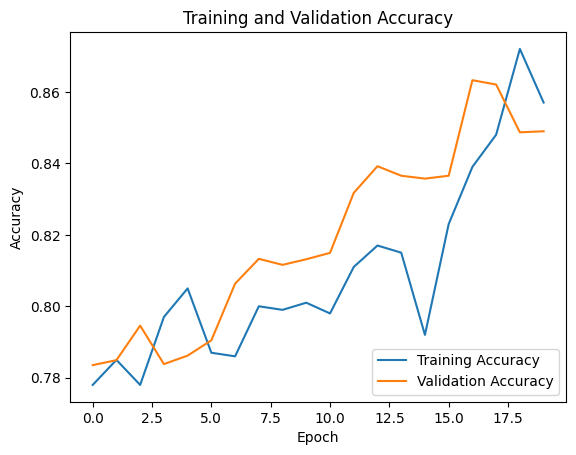

In [10]:
# Visualize Accuracy
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.plot(range(epochs), acc, label='Training Accuracy')
plt.plot(range(epochs), val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

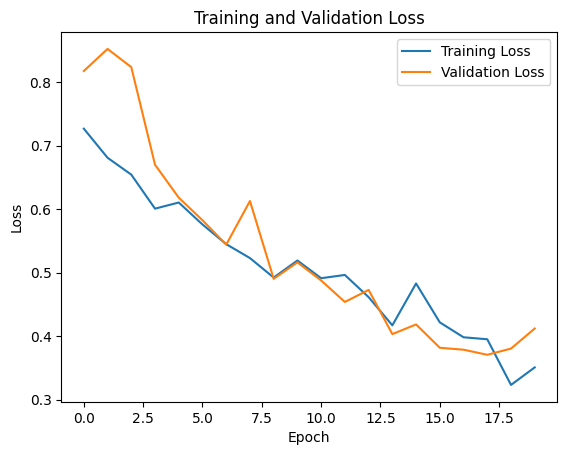

In [11]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']
plt.plot(range(epochs), train_loss, label='Training Loss')
plt.plot(range(epochs), val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()